# ****Part A – Theoretical Foundation (Short Notes & Explanation) :****

# ***1. What is inferential statistics ?***

# **Inferential statistics is a branch of statistics that uses sample data to draw conclusions about a larger population. It helps estimate population parameters, make predictions, and test assumptions using statistical methods.**

# ***2. What is hypothesis testing and its components ?***

# **Hypothesis testing is a statistical method used to determine whether there is sufficient evidence to support a claim about a population. Its main components are the null hypothesis (\(H_0\)), alternative hypothesis (\(H_1\)), significance level (\(\alpha\)), test statistic, p-value, and conclusion.**

# ***3. Explain Confidence Interval and Critical Value.***

# **A confidence interval is a range of values used to estimate an unknown population parameter at a specified confidence level, such as 95%. A critical value is a threshold obtained from a statistical distribution that helps determine whether to reject the null hypothesis.**

# ***4. Define p-value.***

# **A p-value is the probability of obtaining results as extreme as, or more extreme than, the observed results, assuming the null hypothesis is true. If the p-value is less than the significance level (usually 0.05), the null hypothesis is rejected.**

# ***5. Differentiate Type I and Type II Errors.***

# **Type I Error: Rejecting the null hypothesis when it is actually true; this is known as a false positive.**

# **Type II Error: Failing to reject the null hypothesis when it is actually false; this is known as a false negative.**



# ***6. Brief Descriptions of z-test , t-test , chi-square test , and ANOVA test.***

# **Z-test: A statistical test used to compare means or proportions when normal-based assumptions are appropriate, often with a known population standard deviation for mean testing.**

# **T-test: A statistical test used to determine whether there is a significant difference between means, particularly when the population standard deviation is unknown.**

# **Chi-square test: A statistical test used to determine whether a significant association exists between categorical variables or whether observed frequencies differ from expected frequencies.**

# **ANOVA test: Analysis of Variance (ANOVA) is used to determine whether there are statistically significant differences among the means of three or more groups.**

# ***7. What is Covariance ?***

# **Covariance is a statistical measure that indicates how two variables change together. Positive covariance means the variables tend to increase together, while negative covariance means one tends to increase as the other decreases.**

# ***8. What is Correlation ?***

# **Correlation is a statistical measure that describes the strength and direction of the relationship between two variables. Its coefficient ranges from \(-1\) to \(+1\), where \(+1\) indicates perfect positive correlation, \(-1\) indicates perfect negative correlation, and \(0\) indicates no linear correlation.**

# ****Part B – Data Analysis & Testing Tasks :****

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [4]:
DF = pd.read_csv(r"Derivable Judgement.csv")

In [5]:
DF.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,f47ac10b-58cc-4372-a567-0e02b2c3d479,26-35,29,68,Female,North,Non-Smoker,Weekly,22.4,118.5,False,False,182.4,92.1,2026-01-15
1,a1b2c3d4-e5f6-7a8b-9c0d-1e2f3a4b5c6d,46-60,52,85,Male,South,Smoker,Rarely,28.6,135.2,True,True,225.8,115.4,2026-01-16
2,b2c3d4e5-f6a7-8b9c-0d1e-2f3a4b5c6d7e,18-25,22,60,Female,East,Non-Smoker,Daily,20.1,110.0,False,False,160.5,88.0,2026-01-18
3,c3d4e5f6-a7b8-9c0d-1e2f-3a4b5c6d7e8f,36-45,41,78,Male,West,Former Smoker,Weekly,25.3,124.0,False,True,198.1,102.3,2026-01-20
4,d4e5f6a7-b8c9-0d1e-2f3a-4b5c6d7e8f9a,60+,67,72,Female,North,Non-Smoker,Rarely,27.0,140.5,True,True,240.2,128.5,2026-01-22


# ***1. Formulate at least two hypotheses from the dataset. Example :***
# ***H₀ : Smoking has no effect on Diabetes prevalence.***
# ***H₁ : Smoking affects Diabetes prevalence.***

In [6]:
diabetes_age = DF.loc[DF["diabetes"], "age"]
no_diabetes_age = DF.loc[~DF["diabetes"], "age"]

t_stat, p_value = stats.ttest_ind(
    diabetes_age,
    no_diabetes_age,
    equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))

if p_value < 0.05:
    print("Reject H0: Significant difference in mean age.")
else:
    print("Fail to reject H0: Insufficient evidence of a difference.")

T-statistic: 15.618
P-value: 0.0
Reject H0: Significant difference in mean age.


# ***2. Calculate Confidence Intervals for key numerical data like age, weight, etc.***

In [7]:
age = DF["age"]
n = len(age)

mean_age = age.mean()
standard_error = stats.sem(age)

critical_value = stats.t.ppf(0.975, df=n - 1)

margin_error = critical_value * standard_error

lower = mean_age - margin_error
upper = mean_age + margin_error

print("Mean age:", round(mean_age, 2))
print("Critical t-value:", round(critical_value, 3))
print("95% Confidence Interval:",
      (round(lower, 2), round(upper, 2)))


Mean age: 43.32
Critical t-value: 1.976
95% Confidence Interval: (np.float64(40.58), np.float64(46.06))


# ***3. Find the Critical Value and p-value to interpret the test results.***

In [8]:
smoker_bmi = DF.loc[
    DF["smoking_status"] == "Smoker", "bmi"
]

nonsmoker_bmi = DF.loc[
    DF["smoking_status"] == "Non-Smoker", "bmi"
]

t_stat, p_value = stats.ttest_ind(
    smoker_bmi,
    nonsmoker_bmi,
    equal_var=False
)

print("P-value:", round(p_value, 5))
print("Statistically significant:", p_value < 0.05)


P-value: 0.0
Statistically significant: True


# ***4. Perform z-test or t-test based on sample size (mean comparison across groups).***

In [9]:
sample = DF["bmi"]
population_mean = 25
population_sd = 4

z_stat = (sample.mean() - population_mean) / (
    population_sd / np.sqrt(len(sample))
)

p_z = 2 * stats.norm.sf(abs(z_stat))

print("Z-statistic:", round(z_stat, 3))
print("P-value:", round(p_z, 5))



group1 = DF.loc[DF["diabetes"], "bmi"]
group2 = DF.loc[~DF["diabetes"], "bmi"]

t_stat, p_t = stats.ttest_ind(
    group1, group2, equal_var=False
)

print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_t, 5))


Z-statistic: 2.661
P-value: 0.00779
T-statistic: 10.773
P-value: 0.0


# ***5. Conduct a chi-square test on categorical data (e.g., Smoking habit vs Disease).***

In [10]:
table = pd.crosstab(
    DF["smoking_status"],
    DF["diabetes"]
)

chi2, p_chi, dof, expected = stats.chi2_contingency(table)

print("Contingency Table:")
print(table)
print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("P-value:", round(p_chi, 5))

if p_chi < 0.05:
    print("Reject H0: Evidence of an association.")
else:
    print("Fail to reject H0: Insufficient evidence of an association.")


Contingency Table:
diabetes        False  True 
smoking_status              
Former Smoker      16     14
Non-Smoker         59     22
Smoker             15     22
Chi-square statistic: 12.001
Degrees of freedom: 2
P-value: 0.00248
Reject H0: Evidence of an association.


# ***6. Perform an ANOVA test to check if age groups significantly differ in disease rate.***

In [11]:
groups = [
    group["bmi"].values
    for _ , group in DF.groupby("smoking_status")
]

f_stat, p_anova = stats.f_oneway(*groups)

print("F-statistic:", round(f_stat, 3))
print("P-value:", round(p_anova, 5))

if p_anova < 0.05:
    print("Reject H0: At least one group mean differs.")
else:
    print("Fail to reject H0: Insufficient evidence of a mean difference.")


F-statistic: 87.893
P-value: 0.0
Reject H0: At least one group mean differs.


# ***7. Calculate Covariance and Correlation between continuous variables (e.g., Age vs. BMI).***

In [12]:
covariance = DF[["age", "bmi"]].cov()

print("Covariance Matrix:")
print(covariance)


Covariance Matrix:
            age        bmi
age  283.973295  35.778061
bmi   35.778061  15.022432


# ***8. Clearly state the result and interpretation (Accept/Reject H₀) of each test performed.***

Correlation Matrix:
          age       bmi
age  1.000000  0.547782
bmi  0.547782  1.000000
Age vs BMI correlation: 0.548
P-value: 0.0


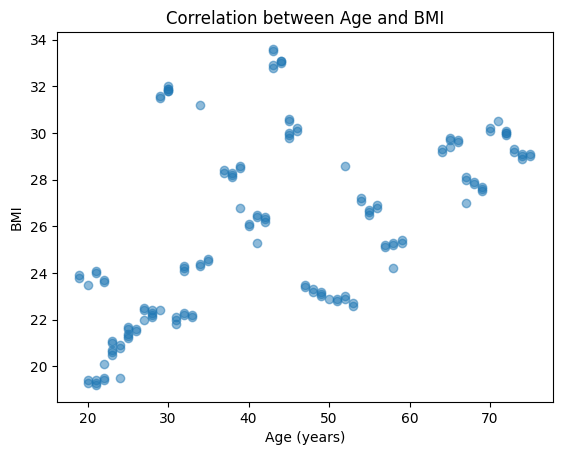

In [13]:
correlation = DF[["age", "bmi"]].corr()

print("Correlation Matrix:")
print(correlation)

r, p = stats.pearsonr(DF["age"], DF["bmi"])

print("Age vs BMI correlation:", round(r, 3))
print("P-value:", round(p, 5))

plt.scatter(DF["age"], DF["bmi"], alpha=0.5)
plt.xlabel("Age (years)")
plt.ylabel("BMI")
plt.title("Correlation between Age and BMI")
plt.show()

In [14]:
DF.to_csv("derivable_judgement_dataset.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!
